In [11]:
# IMPORTS LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings
import os
warnings.filterwarnings('ignore')

# Load data 
train_path = r"D:\bhopal-pollutant-prediction\processed_data\train_engineered.csv"
test_path = r"D:\bhopal-pollutant-prediction\processed_data\test_engineered.csv"
train = pd.read_csv(train_path, parse_dates=['datetime'], index_col='datetime')
test = pd.read_csv(test_path, parse_dates=['datetime'], index_col='datetime')

In [12]:
# Model imports
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler

plt.rcParams['figure.figsize'] = (14, 8)
sns.set_style("whitegrid")

In [13]:
# PREPARE FEATURES (Safe features only) 
TIME_LEAKERS = ['year', 'month', 'day', 'day_of_month', 'week_of_year']

SAFE_TIME_FEATURES = ['hour_sin', 'hour_cos', 'month_sin', 'month_cos',
                      'hour_of_day', 'day_of_week', 'is_weekend', 
                      'is_night', 'is_morning_rush', 'is_evening_rush', 'season']

WEATHER_FEATURES = ['temp', 'humidity', 'windspeed', 'winddir', 'precip',
                    'cloudcover', 'visibility', 'sealevelpressure', 'uvindex']

# Get lag and rolling features
lag_features = [col for col in train.columns if '_lag_' in col]
rolling_features = [col for col in train.columns if '_roll_' in col]

# Combine all safe features
all_features = SAFE_TIME_FEATURES + WEATHER_FEATURES + lag_features + rolling_features
all_features = [f for f in all_features if f in train.columns]
all_features = [f for f in all_features if f not in TIME_LEAKERS]
all_features = list(set(all_features))

print(f"✅ Using {len(all_features)} safe features")

# Targets (pollutants to predict)
TARGETS = ['PM25_Idgah_Hills', 'PM10_Idgah_Hills', 'NO2_Idgah_Hills']
print(f"🎯 Predicting: {len(TARGETS)} pollutants")

✅ Using 146 safe features
🎯 Predicting: 3 pollutants


In [14]:
# SPLIT DATA 
X_train = train[all_features]
X_test = test[all_features]
y_train = train[TARGETS]
y_test = test[TARGETS]

print(f"DATA SHAPES:")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

DATA SHAPES:
X_train: (13632, 146)
X_test:  (3408, 146)
y_train: (13632, 3)
y_test:  (3408, 3)


In [15]:
#Adding cross Validation function 
def evaluate_model_cv(model, X, y, cv_splits=5, scoring='r2'):
    """
    Evaluate model with time-series cross-validation
    """
    tscv = TimeSeriesSplit(n_splits=cv_splits)
    
    cv_scores = cross_val_score(
        model, X, y, 
        cv=tscv,
        scoring=scoring,
        n_jobs=-1,
        verbose=0
    )
    return cv_scores

# Test cross-validation on XGBoost
print("🔍 Testing Cross-Validation on XGBoost...")
for target in TARGETS:
    model = xgb.XGBRegressor(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
    
    cv_scores = evaluate_model_cv(model, X_train, y_train[target], cv_splits=3)
    print(f"   {target}: R² = {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")

🔍 Testing Cross-Validation on XGBoost...
   PM25_Idgah_Hills: R² = 0.9926 (±0.0024)
   PM10_Idgah_Hills: R² = 0.9884 (±0.0033)
   NO2_Idgah_Hills: R² = 0.9835 (±0.0090)


In [16]:
print("TRAINING MODELS WITH CROSS-VALIDATION")

# Store all trained models
all_models_dict = {}

for target in TARGETS:
    print(f"\n Training for {target}")
   
    
    # 1. XGBoost
    print("   XGBoost:")
    xgb_model = xgb.XGBRegressor(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1
    )
    
    # Cross-validation
    xgb_cv_scores = evaluate_model_cv(xgb_model, X_train, y_train[target], cv_splits=3)
    print(f"     CV R²: {xgb_cv_scores.mean():.4f} (±{xgb_cv_scores.std():.4f})")
    
    # Train final model
    xgb_model.fit(X_train, y_train[target])
    y_pred_test = xgb_model.predict(X_test)
    test_r2 = r2_score(y_test[target], y_pred_test)
    print(f"     Test R²: {test_r2:.4f}")
    
    # Store
    all_models_dict[f'XGBoost_{target}'] = xgb_model
    
    # 2. LightGBM
    print("   LightGBM:")
    lgb_model = lgb.LGBMRegressor(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    
    lgb_cv_scores = evaluate_model_cv(lgb_model, X_train, y_train[target], cv_splits=3)
    print(f"     CV R²: {lgb_cv_scores.mean():.4f} (±{lgb_cv_scores.std():.4f})")
    
    lgb_model.fit(X_train, y_train[target])
    y_pred_test = lgb_model.predict(X_test)
    test_r2 = r2_score(y_test[target], y_pred_test)
    print(f"     Test R²: {test_r2:.4f}")
    
    all_models_dict[f'LightGBM_{target}'] = lgb_model

TRAINING MODELS WITH CROSS-VALIDATION

 Training for PM25_Idgah_Hills
   XGBoost:
     CV R²: 0.9927 (±0.0025)
     Test R²: 0.9899
   LightGBM:
     CV R²: 0.9931 (±0.0023)
     Test R²: 0.9910

 Training for PM10_Idgah_Hills
   XGBoost:
     CV R²: 0.9882 (±0.0032)
     Test R²: 0.9960
   LightGBM:
     CV R²: 0.9901 (±0.0026)
     Test R²: 0.9963

 Training for NO2_Idgah_Hills
   XGBoost:
     CV R²: 0.9836 (±0.0089)
     Test R²: 0.9885
   LightGBM:
     CV R²: 0.9864 (±0.0067)
     Test R²: 0.9899


 FEATURE IMPORTANCE ANALYSIS

 Top 10 Features for PM25_Idgah_Hills:
    1. PM25_Idgah_Hills_roll_mean_3h : 0.5597
    2. PM25_Idgah_Hills_roll_min_3h  : 0.1299
    3. PM25_Idgah_Hills_lag_1h       : 0.0948
    4. PM25_Idgah_Hills_roll_max_3h  : 0.0895
    5. PM25_Idgah_Hills_roll_mean_6h : 0.0162
    6. PM25_Idgah_Hills_roll_min_6h  : 0.0135
    7. PM25_Idgah_Hills_roll_max_6h  : 0.0083
    8. PM25_Idgah_Hills_lag_2h       : 0.0078
    9. PM25_Idgah_Hills_roll_max_12h : 0.0056
   10. PM10_Idgah_Hills_lag_2h       : 0.0052


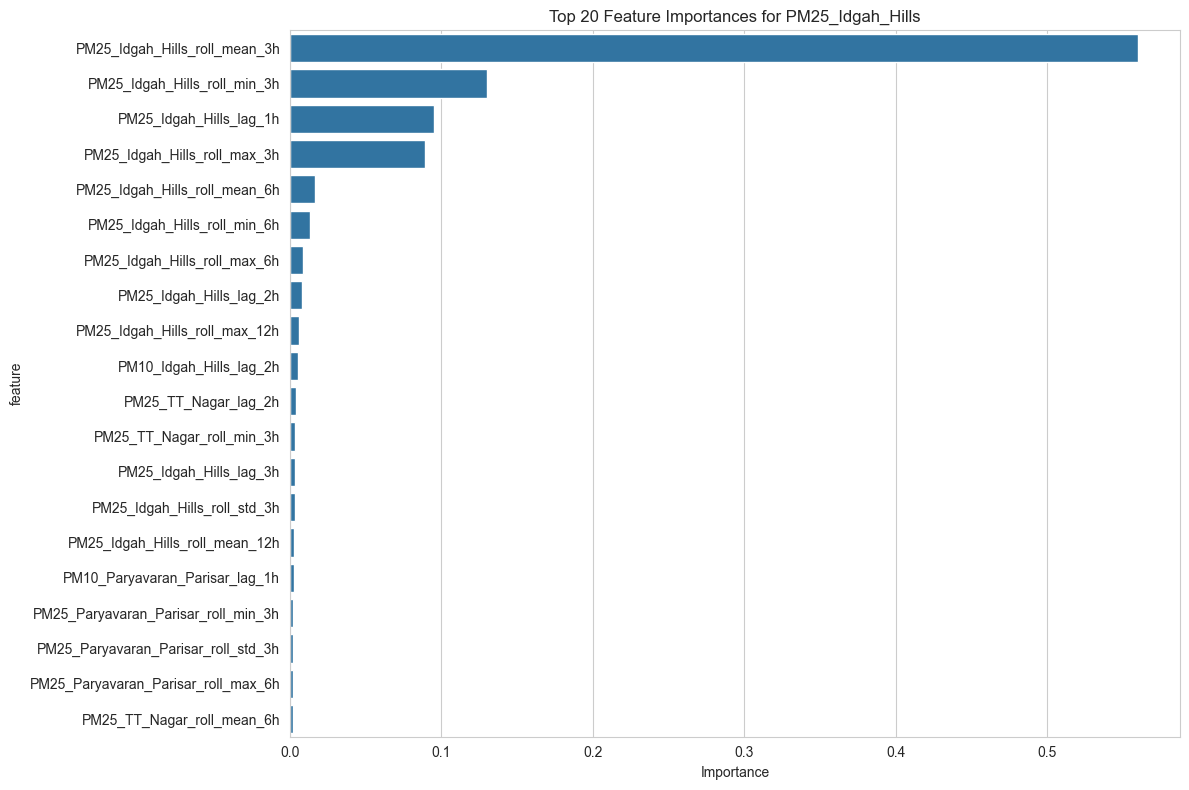


 Correlation Matrix (first 20 features):


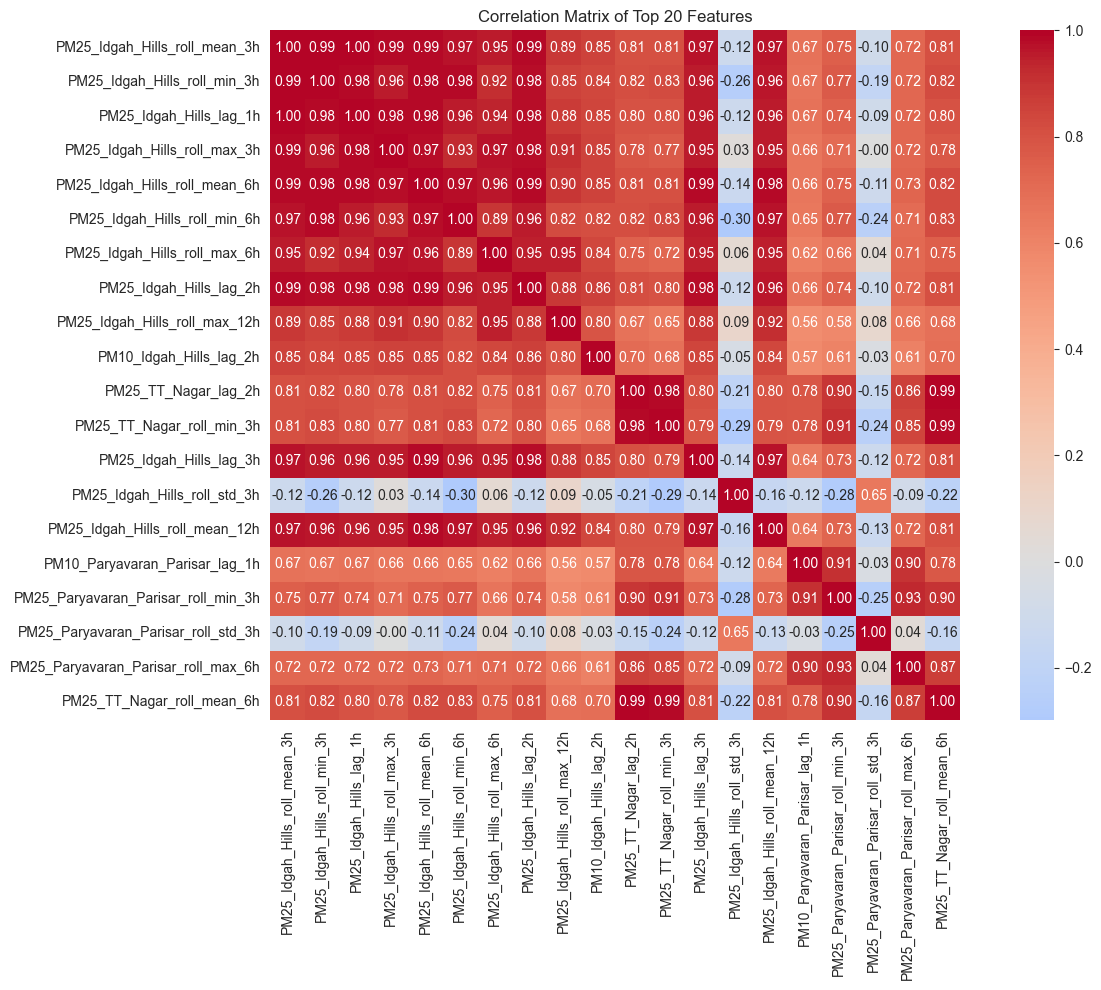

In [17]:
print(" FEATURE IMPORTANCE ANALYSIS")


# Analyze for PM2.5 (most important target)
target = 'PM25_Idgah_Hills'
model = all_models_dict[f'XGBoost_{target}']

# Get feature importance
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\n Top 10 Features for {target}:")
for i, (feature, importance) in enumerate(zip(importance_df['feature'].head(10), 
                                               importance_df['importance'].head(10)), 1):
    print(f"   {i:2d}. {feature:30s}: {importance:.4f}")

# Plot top 20 features
plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df.head(20), x='importance', y='feature')
plt.title(f'Top 20 Feature Importances for {target}')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# Correlation analysis (just for visualization)
print("\n Correlation Matrix (first 20 features):")
top_features = importance_df['feature'].head(20).tolist()
correlation_matrix = X_train[top_features].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, 
            cmap='coolwarm', 
            center=0, 
            annot=True, 
            fmt='.2f',
            square=True)
plt.title('Correlation Matrix of Top 20 Features')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [18]:
print(" REGULARIZATION AND OVERFITTING PREVENTION")


# Create train/validation split (no shuffle for time series!)
def train_with_validation(model, X_train_full, y_train_full, target, model_name):
    """
    Train model with validation set to monitor overfitting
    """
    # Split without shuffling (time series!)
    X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
        X_train_full, y_train_full[target], 
        test_size=0.2, 
        shuffle=False
    )
    
    # Train model
    model.fit(X_train_split, y_train_split)
    
    # Evaluate
    train_pred = model.predict(X_train_split)
    val_pred = model.predict(X_val_split)
    
    train_r2 = r2_score(y_train_split, train_pred)
    val_r2 = r2_score(y_val_split, val_pred)
    
    print(f"   {model_name}: Train R² = {train_r2:.4f}, Val R² = {val_r2:.4f}")
    
    # Calculate overfitting gap
    overfit_gap = train_r2 - val_r2
    if overfit_gap > 0.05:
        print(f"   ⚠️  Possible overfitting (gap = {overfit_gap:.4f})")
    
    return model, overfit_gap

# Test with different regularization strengths
print("\n Testing regularization for PM2.5:")
target = 'PM25_Idgah_Hills'

regularization_params = [
    {'reg_alpha': 0.1, 'reg_lambda': 1.0, 'name': 'Low L1'},
    {'reg_alpha': 1.0, 'reg_lambda': 1.0, 'name': 'Medium L1'},
    {'reg_alpha': 10.0, 'reg_lambda': 1.0, 'name': 'High L1'},
]

for params in regularization_params:
    model = xgb.XGBRegressor(
        n_estimators=200,
        max_depth=4,  # Reduced from 5
        learning_rate=0.02,  # Reduced from 0.05
        subsample=0.7,
        colsample_bytree=0.7,
        reg_alpha=params['reg_alpha'],
        reg_lambda=params['reg_lambda'],
        random_state=42,
        n_jobs=-1
    )
    
    trained_model, gap = train_with_validation(model, X_train, y_train, target, params['name'])
    all_models_dict[f'XGB_Reg_{params["name"]}_{target}'] = trained_model

 REGULARIZATION AND OVERFITTING PREVENTION

 Testing regularization for PM2.5:
   Low L1: Train R² = 0.9940, Val R² = 0.9828
   Medium L1: Train R² = 0.9939, Val R² = 0.9824
   High L1: Train R² = 0.9937, Val R² = 0.9822


 LSTM IMPLEMENTATION

🔧 Setting up LSTM environment...
✅ TensorFlow 2.20.0 already installed

 Implementing LSTM for pollution prediction...

 Preparing LSTM data for PM25_Idgah_Hills
LSTM Training Data Prepared:
  • Input sequences shape: (13608, 24, 146)
  • Target shape: (13608, 1)
  • Time steps: 24
  • Features per timestep: 146

 Train/Validation Split:
  • Training samples: 10886
  • Validation samples: 2722

 Building LSTM model...
✅ LSTM Model Architecture:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 24, 128)        │       140,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 24, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,169 (793.63 KB)

 Trainable params: 203,169 (793.63 KB)

 Non-trainable params: 0 (0.00 B)


 Training LSTM model...
This may take several minutes depending on your hardware.
Epoch 1/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - loss: 0.1824 - mae: 0.1174 - mse: 0.0274 - val_loss: 0.0806 - val_mae: 0.0756 - val_mse: 0.0096 - learning_rate: 0.0010
Epoch 2/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - loss: 0.0645 - mae: 0.0853 - mse: 0.0149 - val_loss: 0.0432 - val_mae: 0.0706 - val_mse: 0.0089 - learning_rate: 0.0010
Epoch 3/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 16s 47ms/step - loss: 0.0397 - mae: 0.0816 - mse: 0.0138 - val_loss: 0.0276 - val_mae: 0.0678 - val_mse: 0.0084 - learning_rate: 0.0010
Epoch 4/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 42s 122ms/step - loss: 0.0279 - mae: 0.0763 - mse: 0.0127 - val_loss: 0.0228 - val_mae: 0.0836 - val_mse: 0.0111 - learning_rate: 0.0010
Epoch 5/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 37s 109ms/step - loss: 0.0217 - mae: 0.0738 - mse: 0.0121 - val_loss: 0.0170 - val_mae: 0.0707 - val_mse: 0.0091 - learning_rate: 0.0010
Epoch 6/50
341/341 ━━━━━━━━━━━━━━━━

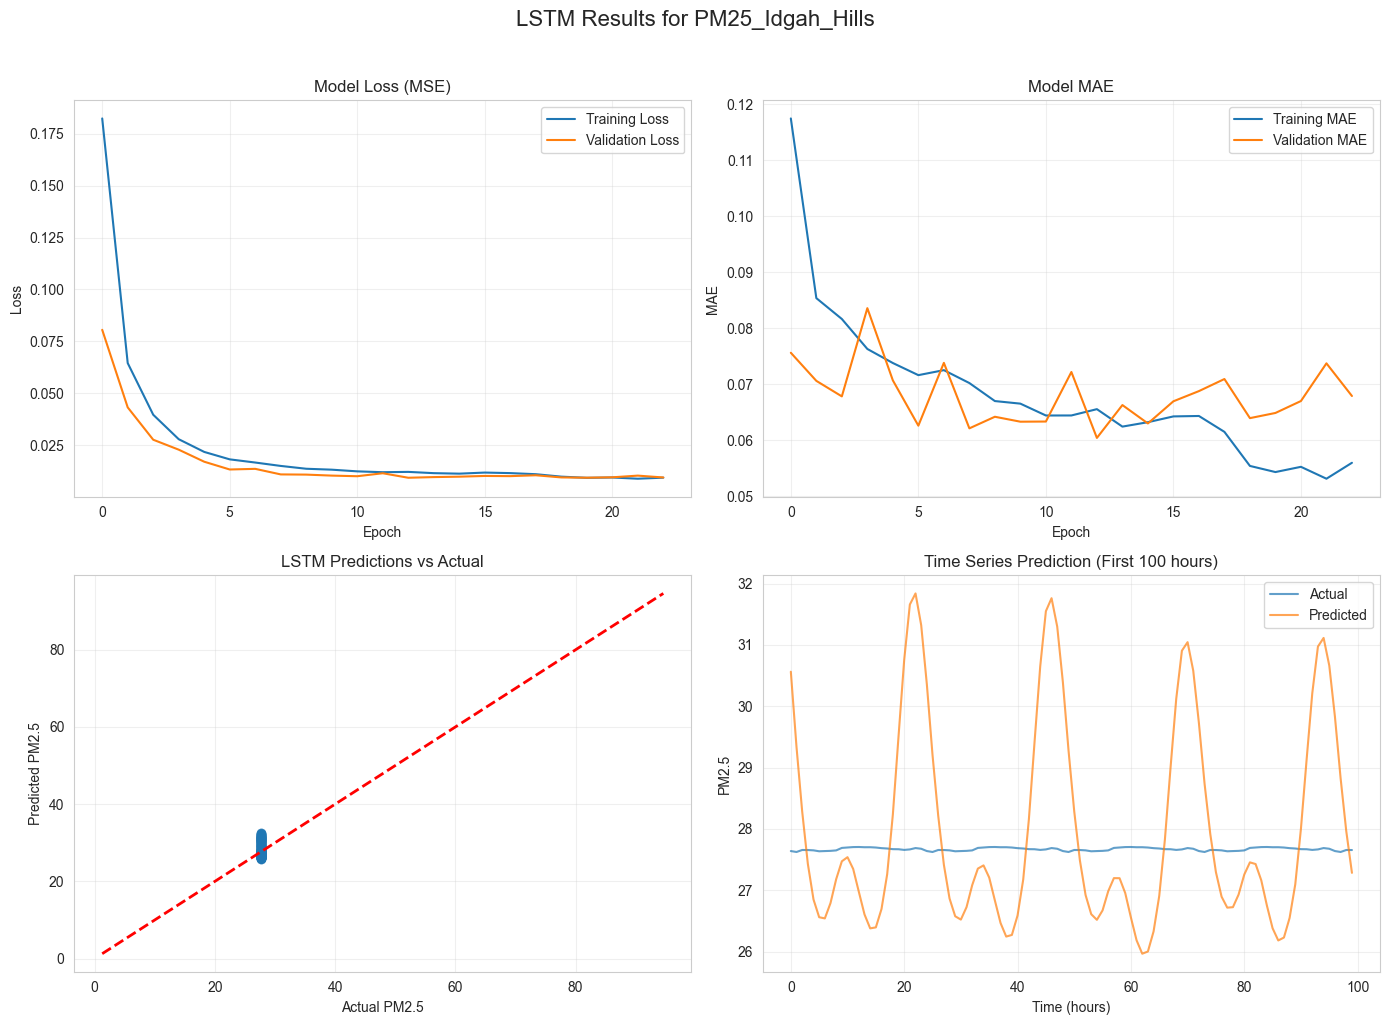


 Saving LSTM model and artifacts...
✅ LSTM model saved: D:\bhopal-pollutant-prediction\lstm_models\lstm_PM25_Idgah_Hills.h5
✅ Scalers saved in: D:\bhopal-pollutant-prediction\lstm_models
✅ Training history saved: D:\bhopal-pollutant-prediction\lstm_models\lstm_training_history.csv
LSTM IMPLEMENTATION COMPLETED SUCCESSFULLY! 


In [19]:
print(" LSTM IMPLEMENTATION")


def install_tensorflow():
    """Install TensorFlow and verify installation"""
    print("Installing TensorFlow...")
    try:
        # Try to install TensorFlow
        import subprocess
        import sys
        import os
        
        # Initialize dictionary to store all models
        all_models_dict = {}
        print("✅ Model dictionary initialized")
        # Install TensorFlow
        !pip install tensorflow --quiet
        
        print("✅ TensorFlow installed successfully!")
        return True
    except Exception as e:
        print(f"❌ Installation failed: {e}")
        print("\nTrying CPU-only version...")
        try:
            !pip install tensorflow-cpu --quiet
            print("✅ TensorFlow-CPU installed successfully!")
            return True
        except Exception as e2:
            print(f"❌ CPU installation also failed: {e2}")
            return False

def setup_lstm_environment():
    """Setup LSTM environment and check dependencies"""
    print("\n🔧 Setting up LSTM environment...")
    
    # Check if TensorFlow is already installed
    try:
        import tensorflow as tf
        print(f"✅ TensorFlow {tf.__version__} already installed")
        return True, tf
    except ImportError:
        print("❌ TensorFlow not found. Installing...")
        
        # Ask for installation

        print("TensorFlow is required for LSTM.")
        print("It may take a few minutes to install.")
        
        
        response = input("Do you want to install TensorFlow now? (y/n): ")
        
        if response.lower() == 'y':
            if install_tensorflow():
                try:
                    import tensorflow as tf
                    print(f"TensorFlow {tf.__version__} ready!")
                    return True, tf
                except:
                    return False, None
            else:
                return False, None
        else:
            print("Skipping TensorFlow installation.")
            return False, None

# Setup environment
tensorflow_available, tf = setup_lstm_environment()

if tensorflow_available:
    from tensorflow import keras
    from tensorflow.keras import layers, callbacks
    from sklearn.preprocessing import MinMaxScaler
    
    print("\n Implementing LSTM for pollution prediction...")
    
    # We'll implement LSTM for PM2.5 (most important target)
    target = 'PM25_Idgah_Hills'
    
    print(f"\n Preparing LSTM data for {target}")
    
    
    # 1. Scale the data (LSTMs work better with scaled data)
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()
    
    X_scaled = scaler_X.fit_transform(X_train)
    y_scaled = scaler_y.fit_transform(y_train[[target]])
    
    # 2. Create sequences for LSTM
    def create_sequences(X, y, time_steps=24):
        """
        Create sequences for LSTM
        X: features
        y: target
        time_steps: number of hours to look back
        """
        X_seq, y_seq = [], []
        for i in range(len(X) - time_steps):
            X_seq.append(X[i:(i + time_steps)])
            y_seq.append(y[i + time_steps])
        return np.array(X_seq), np.array(y_seq)
    
    time_steps = 24  # Look back 24 hours (1 day)
    X_seq, y_seq = create_sequences(X_scaled, y_scaled, time_steps)
    
    print(f"LSTM Training Data Prepared:")
    print(f"  • Input sequences shape: {X_seq.shape}")  # (samples, time_steps, features)
    print(f"  • Target shape: {y_seq.shape}")
    print(f"  • Time steps: {time_steps}")
    print(f"  • Features per timestep: {X_seq.shape[2]}")
    
    # 3. Split into train/validation (80/20)
    train_size = int(len(X_seq) * 0.8)
    
    X_train_seq = X_seq[:train_size]
    X_val_seq = X_seq[train_size:]
    y_train_seq = y_seq[:train_size]
    y_val_seq = y_seq[train_size:]
    
    print(f"\n Train/Validation Split:")
    print(f"  • Training samples: {len(X_train_seq)}")
    print(f"  • Validation samples: {len(X_val_seq)}")
    
    # 4. Build LSTM model
    print("\n Building LSTM model...")
    
    lstm_model = keras.Sequential([
        # First LSTM layer
        layers.LSTM(128, 
                   activation='relu', 
                   return_sequences=True,  # Return sequences for next LSTM
                   input_shape=(time_steps, X_seq.shape[2]),
                   kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.Dropout(0.3),  # Dropout for regularization
        
        # Second LSTM layer
        layers.LSTM(64, 
                   activation='relu',
                   return_sequences=True,
                   kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.Dropout(0.3),
        
        # Third LSTM layer
        layers.LSTM(32, 
                   activation='relu',
                   kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.Dropout(0.3),
        
        # Dense layers
        layers.Dense(16, activation='relu'),
        layers.Dense(1)  # Output layer (no activation for regression)
    ])
    
    # 5. Compile the model
    optimizer = keras.optimizers.Adam(learning_rate=0.001)
    
    lstm_model.compile(
        optimizer=optimizer,
        loss='mse',  # Mean Squared Error for regression
        metrics=['mae', 'mse']  # Track MAE and MSE
    )
    
    print("✅ LSTM Model Architecture:")
    lstm_model.summary()
    
    # 6. Define callbacks for better training
    early_stopping = callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,  # Stop after 10 epochs with no improvement
        restore_best_weights=True,
        verbose=1
    )
    
    reduce_lr = callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,  # Reduce LR by half
        patience=5,  # Wait 5 epochs
        min_lr=0.00001,
        verbose=1
    )
    
    # 7. Train the model
    print("\n Training LSTM model...")
    print("This may take several minutes depending on your hardware.")
   
    
    history = lstm_model.fit(
        X_train_seq, y_train_seq,
        epochs=50,  # Start with 50 epochs
        batch_size=32,
        validation_data=(X_val_seq, y_val_seq),
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )
    
    print("✅ Training completed!")
    
    # 8. Evaluate on validation set
    print("\n LSTM Validation Performance:")
    val_loss, val_mae, val_mse = lstm_model.evaluate(X_val_seq, y_val_seq, verbose=0)
    print(f"  • Validation Loss (MSE): {val_loss:.4f}")
    print(f"  • Validation MAE: {val_mae:.4f}")
    
    # 9. Prepare test data for LSTM evaluation
    print("\n🧪 Evaluating on test data...")
    
    # Scale test data
    X_test_scaled = scaler_X.transform(X_test)
    
    # Create test sequences
    # We need to create sequences from test data too
    X_test_seq = []
    y_test_actual = []
    
    # We need at least 'time_steps' data points to create first sequence
    # So we'll start from time_steps index
    for i in range(len(X_test_scaled) - time_steps):
        X_test_seq.append(X_test_scaled[i:(i + time_steps)])
        y_test_actual.append(y_test[target].iloc[i + time_steps])
    
    X_test_seq = np.array(X_test_seq)
    y_test_actual = np.array(y_test_actual)
    
    print(f"Test sequences created: {X_test_seq.shape}")
    
    # 10. Make predictions on test data
    y_test_pred_scaled = lstm_model.predict(X_test_seq, verbose=0)
    
    # Inverse transform predictions to original scale
    y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled).flatten()
    
    # 11. Calculate test metrics
    test_r2 = r2_score(y_test_actual, y_test_pred)
    test_mae = mean_absolute_error(y_test_actual, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test_actual, y_test_pred))
    
    print(f"\n LSTM Test Performance for {target}:")
    print(f"  • Test R² Score: {test_r2:.4f}")
    print(f"  • Test MAE: {test_mae:.4f}")
    print(f"  • Test RMSE: {test_rmse:.4f}")
    
    # 12. Compare with tree-based models
    print("\n Comparison with tree-based models:")
    
    # Get best tree model for this target
    tree_models = [key for key in all_models_dict.keys() 
                   if target in key and ('XGBoost' in key or 'LightGBM' in key)]
    
    for model_key in tree_models[:2]:  # Compare with top 2 tree models
        tree_model = all_models_dict[model_key]
        y_tree_pred = tree_model.predict(X_test)
        tree_r2 = r2_score(y_test[target], y_tree_pred)
        print(f"  • {model_key}: R² = {tree_r2:.4f}")
    
    print(f"  • LSTM: R² = {test_r2:.4f}")
    
    # 13. Visualize training history
    print("\n Plotting training history...")
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot training & validation loss
    axes[0, 0].plot(history.history['loss'], label='Training Loss')
    axes[0, 0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0, 0].set_title('Model Loss (MSE)')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot training & validation MAE
    axes[0, 1].plot(history.history['mae'], label='Training MAE')
    axes[0, 1].plot(history.history['val_mae'], label='Validation MAE')
    axes[0, 1].set_title('Model MAE')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('MAE')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot predictions vs actual (scatter)
    axes[1, 0].scatter(y_test_actual[:200], y_test_pred[:200], alpha=0.6)
    axes[1, 0].plot([y_test_actual.min(), y_test_actual.max()], 
                    [y_test_actual.min(), y_test_actual.max()], 
                    'r--', lw=2)
    axes[1, 0].set_xlabel('Actual PM2.5')
    axes[1, 0].set_ylabel('Predicted PM2.5')
    axes[1, 0].set_title('LSTM Predictions vs Actual')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot predictions over time (first 100 hours)
    axes[1, 1].plot(y_test_actual[:100], label='Actual', alpha=0.7)
    axes[1, 1].plot(y_test_pred[:100], label='Predicted', alpha=0.7)
    axes[1, 1].set_xlabel('Time (hours)')
    axes[1, 1].set_ylabel('PM2.5')
    axes[1, 1].set_title('Time Series Prediction (First 100 hours)')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.suptitle(f'LSTM Results for {target}', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.savefig('lstm_results.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 14. Save the LSTM model and scalers
    print("\n Saving LSTM model and artifacts...")
    
    # Create LSTM directory
    lstm_dir = r"D:\bhopal-pollutant-prediction\lstm_models"
    os.makedirs(lstm_dir, exist_ok=True)
    
    # Save model
    model_path = os.path.join(lstm_dir, f'lstm_{target.replace(".", "_")}.h5')
    lstm_model.save(model_path)
    print(f"✅ LSTM model saved: {model_path}")
    
    # Save scalers
    joblib.dump(scaler_X, os.path.join(lstm_dir, 'lstm_scaler_X.joblib'))
    joblib.dump(scaler_y, os.path.join(lstm_dir, 'lstm_scaler_y.joblib'))
    print(f"✅ Scalers saved in: {lstm_dir}")
    
    # Save training history
    history_df = pd.DataFrame(history.history)
    history_path = os.path.join(lstm_dir, 'lstm_training_history.csv')
    history_df.to_csv(history_path, index=False)
    print(f"✅ Training history saved: {history_path}")
    
    # 15. Store in all_models_dict for comparison
    all_models_dict[f'LSTM_{target}'] = lstm_model
    
    
    print("LSTM IMPLEMENTATION COMPLETED SUCCESSFULLY! ")
    
    
else:
    
    print("⚠️  LSTM SKIPPED")
    print("\nWhy LSTM is valuable but optional:")
    print("1.  Captures temporal patterns in time-series data")
    print("2.  Can learn long-term dependencies (unlike tree models)")
    print("3.  May improve predictions for sequential patterns")
    print("\nTo enable LSTM later:")
    print("Run in a cell: !pip install tensorflow")
    print("Or for lighter install: !pip install tensorflow-cpu")
    print("\nFor now, continuing with tree-based models... ✅")
    
    # Create a placeholder entry
    all_models_dict['LSTM_Skipped'] = None